In [1]:
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from ml.utils import load_binary_classification_macross_model, load_scenario_classification_macross_model, load_attack_classification_macross_model, load_cnn_model, load_resnet_model, load_macross_model, normalise_cm
from ml.metrics import confusion_matrix, get_classification_report
from utils import ID_TO_ATTACK, ID_TO_ATK, ID_TO_SCENARIO

/home/why23/anaconda3/envs/macross/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# plot dpi
mpl.rcParams['figure.dpi'] = 300

# model path
binary_classification_macross_model_path = 'model/binary_classification.macross.model'
scenario_classification_macross_model_path = 'model/scenario_classification.macross.model'
attack_classification_macross_model_path = 'model/attack_classification.macross.model'

# test data path
binary_classification_test_data_path = 'train_test_data/binary_classification/test.parquet'
scenario_classification_test_data_path = 'train_test_data/scenario_classification/test.parquet'
attack_classification_test_data_path = 'train_test_data/attack_classification/test.parquet'

In [3]:
binary_classification_macross = load_binary_classification_macross_model(binary_classification_macross_model_path, gpu=True)
scenario_classification_macross = load_scenario_classification_macross_model(scenario_classification_macross_model_path, gpu=True)
attack_classification_macross = load_attack_classification_macross_model(attack_classification_macross_model_path, gpu=True)

/home/why23/anaconda3/envs/macross/lib/python3.10/site-packages/pytorch_lightning/utilities/cloud_io.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f

In [4]:
def plot_confusion_matrix(cm, labels):
    normalised_cm = normalise_cm(cm)
    fig, ax = plt.subplots(figsize=(12, 12))
    sns.heatmap(
        data=normalised_cm, cmap='YlGnBu',
        xticklabels=labels, yticklabels=labels,
        annot=True, ax=ax, fmt='.2f'
    )
    ax.set_xlabel('Predict labels')
    ax.set_ylabel('True labels')
    fig.show()

In [5]:
binary_macross_cm = confusion_matrix(
    data_path=binary_classification_test_data_path,
    model=binary_classification_macross,
    num_class=len(ID_TO_ATK)
)

/tmp/ipykernel_1026568/3857634299.py:11: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


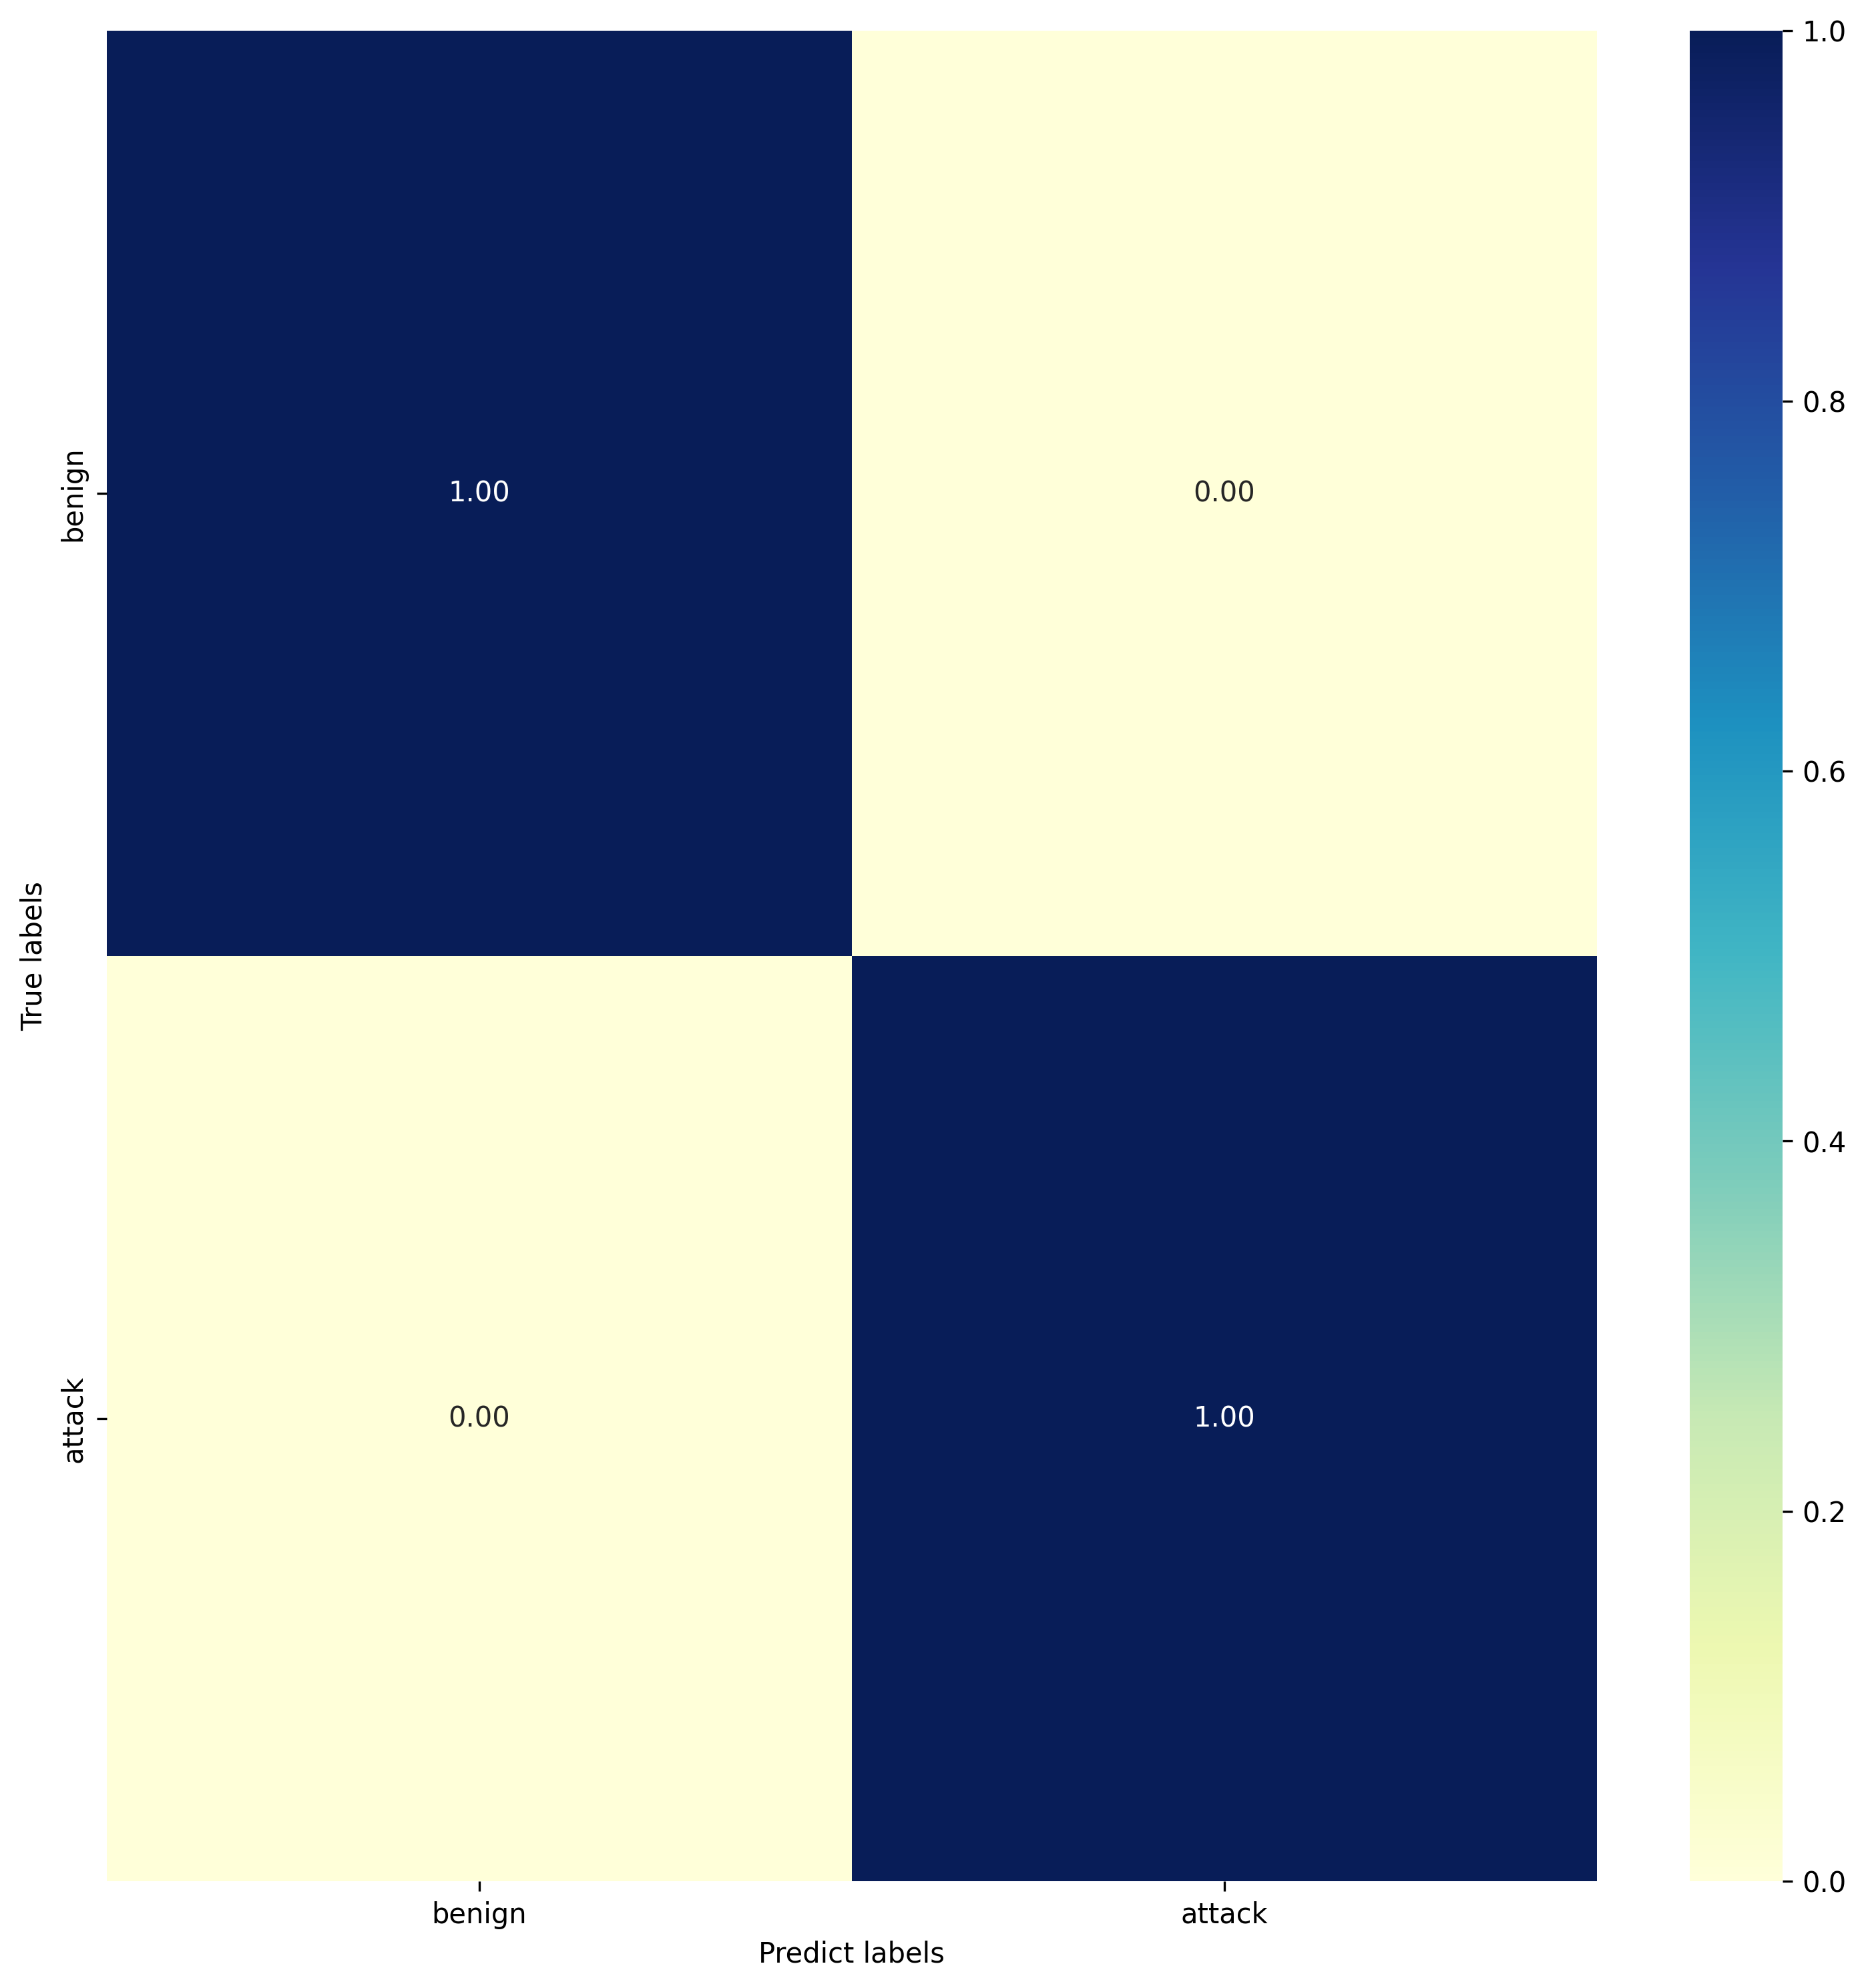

In [6]:
binary_labels = []
for i in sorted(list(ID_TO_ATK.keys())):
    binary_labels.append(ID_TO_ATK[i])

plot_confusion_matrix(binary_macross_cm, binary_labels)

In [7]:
get_classification_report(binary_macross_cm, binary_labels)

,label,acurracy,f1score,precision,recall
0,benign,1.0,1.0,1.0,1.0
1,attack,1.0,1.0,1.0,1.0


/tmp/ipykernel_1026568/3857634299.py:11: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


,label,acurracy,f1score,precision,recall
0,Benign,0.999844,0.999860,1.000000,0.999720
1,Recon,0.999844,0.999766,0.999626,0.999907
2,DoS,0.999844,0.999907,0.999907,0.999907


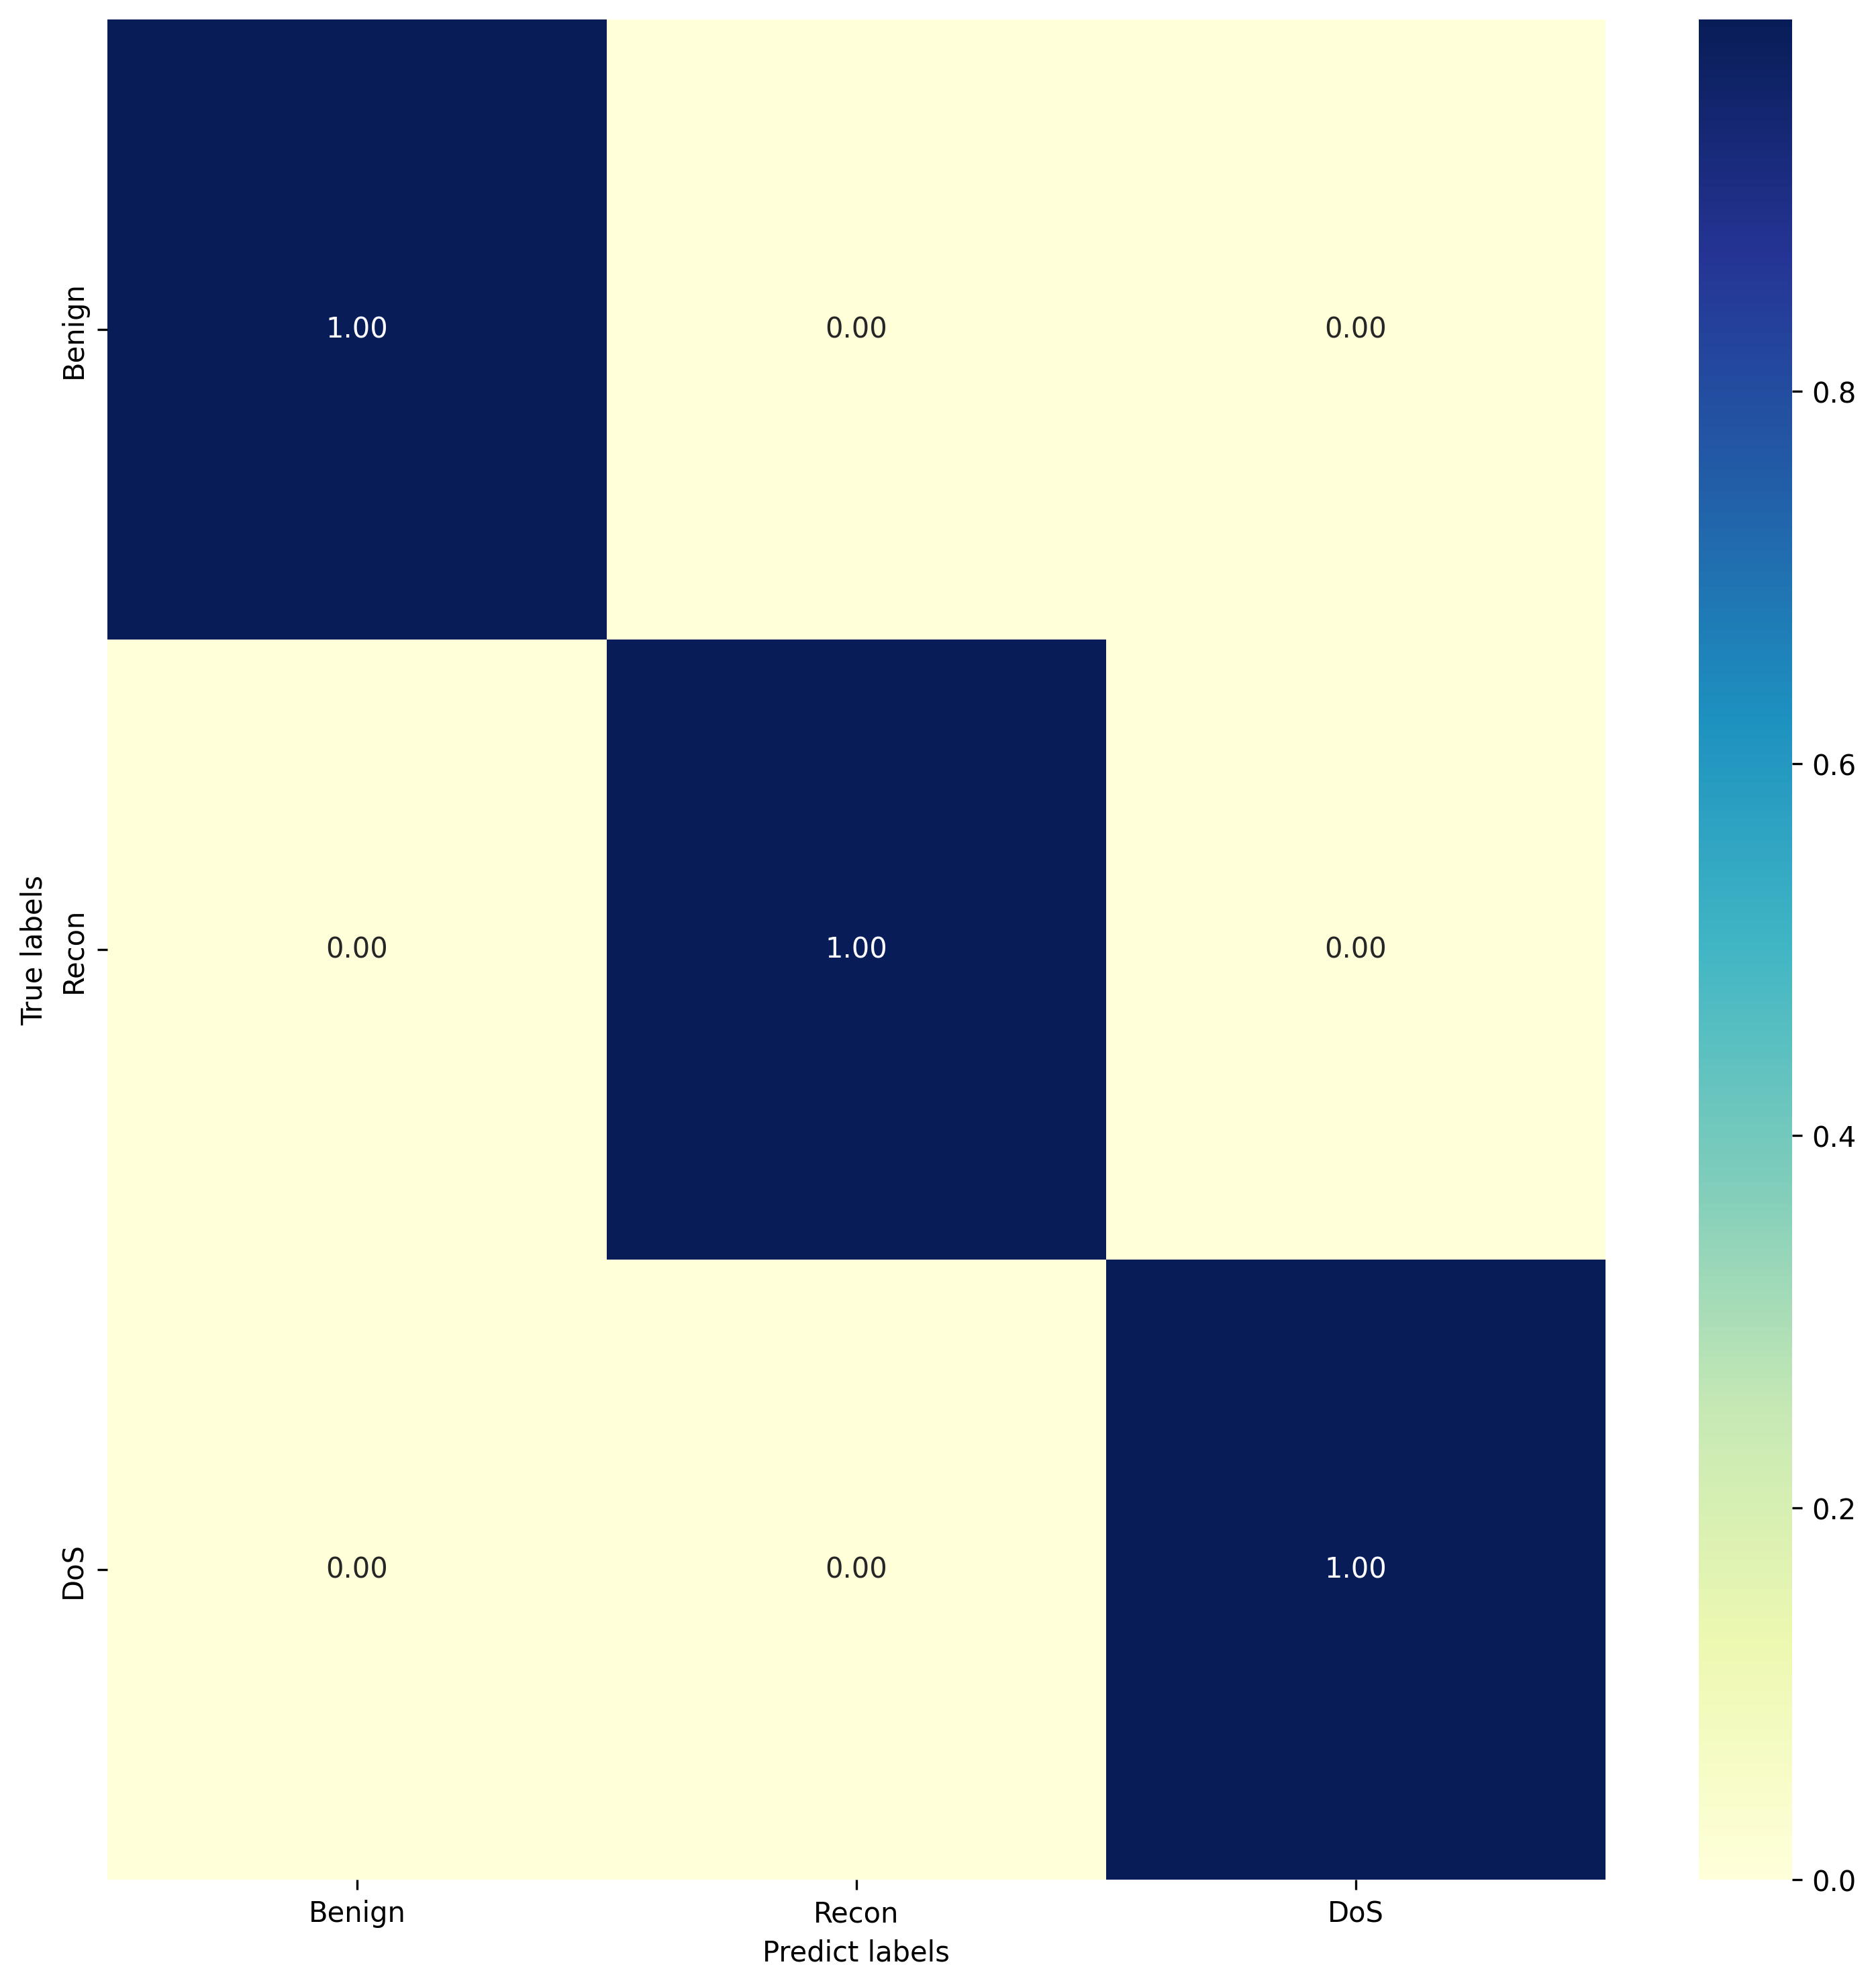

In [8]:
scenario_macross_cm = confusion_matrix(
    data_path=scenario_classification_test_data_path,
    model=scenario_classification_macross,
    num_class=len(ID_TO_SCENARIO)
)

scenario_labels = []
for i in sorted(list(ID_TO_SCENARIO.keys())):
    scenario_labels.append(ID_TO_SCENARIO[i])

plot_confusion_matrix(scenario_macross_cm, scenario_labels)

get_classification_report(scenario_macross_cm, scenario_labels)

/tmp/ipykernel_1026568/3857634299.py:11: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


,label,acurracy,f1score,precision,recall
0,benign,0.984018,0.996130,0.992291,1.000000
1,agressive scan,0.984018,0.973961,0.972345,0.975583
2,icmp flood,0.984018,1.000000,1.000000,1.000000
3,icmp fragmentation,0.984018,1.000000,1.000000,1.000000
4,os fingerprinting,0.984018,0.983462,0.976999,0.990011
5,port scan,0.984018,0.993858,1.000000,0.987791
6,push ack flood,0.984018,0.998338,0.996681,1.000000
7,service detection,0.984018,0.987144,0.994369,0.980022
8,slowloris scan,0.984018,0.990613,0.985714,0.995560
9,syn flood,0.984018,0.932890,0.932373,0.933407


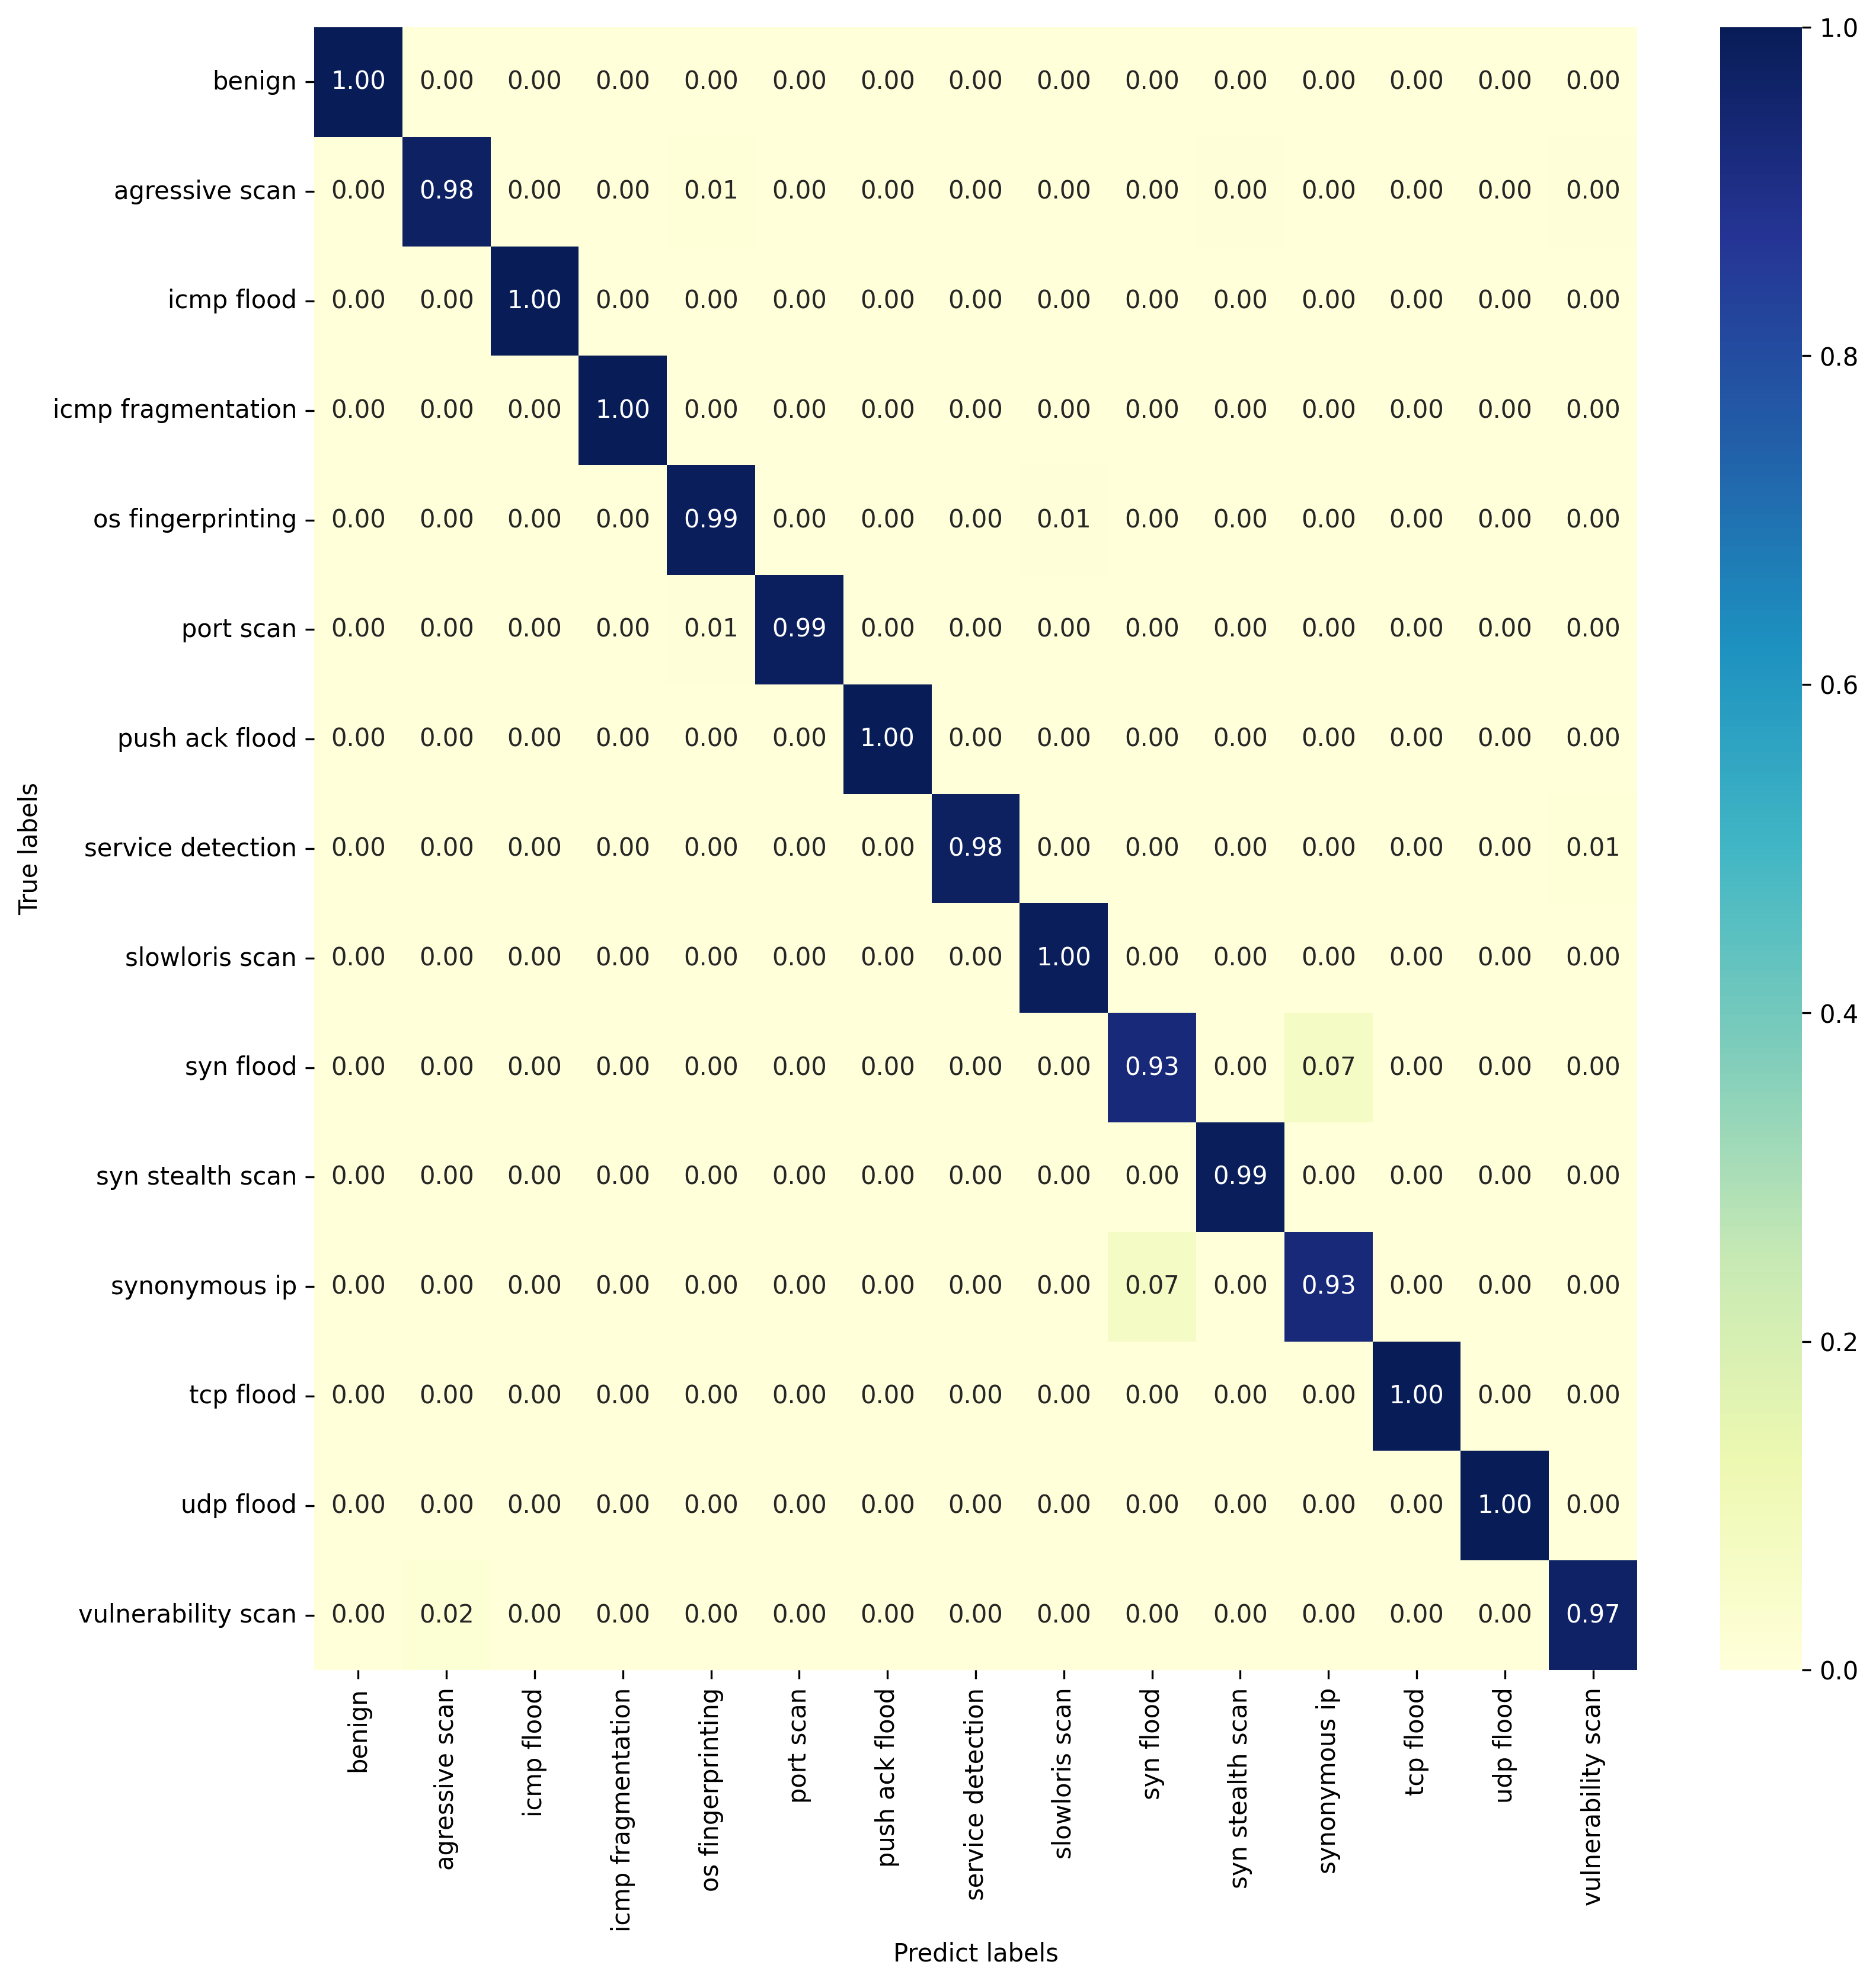

In [9]:
attack_macross_cm = confusion_matrix(
    data_path=attack_classification_test_data_path,
    model=attack_classification_macross,
    num_class=len(ID_TO_ATTACK)
)

attack_labels = []
for i in sorted(list(ID_TO_ATTACK.keys())):
    attack_labels.append(ID_TO_ATTACK[i])

plot_confusion_matrix(attack_macross_cm, attack_labels)

get_classification_report(attack_macross_cm, attack_labels)

/home/why23/anaconda3/envs/macross/lib/python3.10/site-packages/pytorch_lightning/utilities/cloud_io.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f

,label,acurracy,f1score,precision,recall
0,benign,0.794969,0.996130,0.992291,1.000000
1,agressive scan,0.794969,0.982614,0.993197,0.972253
2,icmp flood,0.794969,0.999445,0.998891,1.000000
3,icmp fragmentation,0.794969,1.000000,1.000000,1.000000
4,os fingerprinting,0.794969,0.979681,0.969565,0.990011
5,port scan,0.794969,0.992750,0.997758,0.987791
6,push ack flood,0.794969,0.399289,0.249584,0.997780
7,service detection,0.794969,0.987258,0.985619,0.988901
8,slowloris scan,0.794969,0.996122,0.994469,0.997780
9,syn flood,0.794969,0.000000,NaN,0.000000


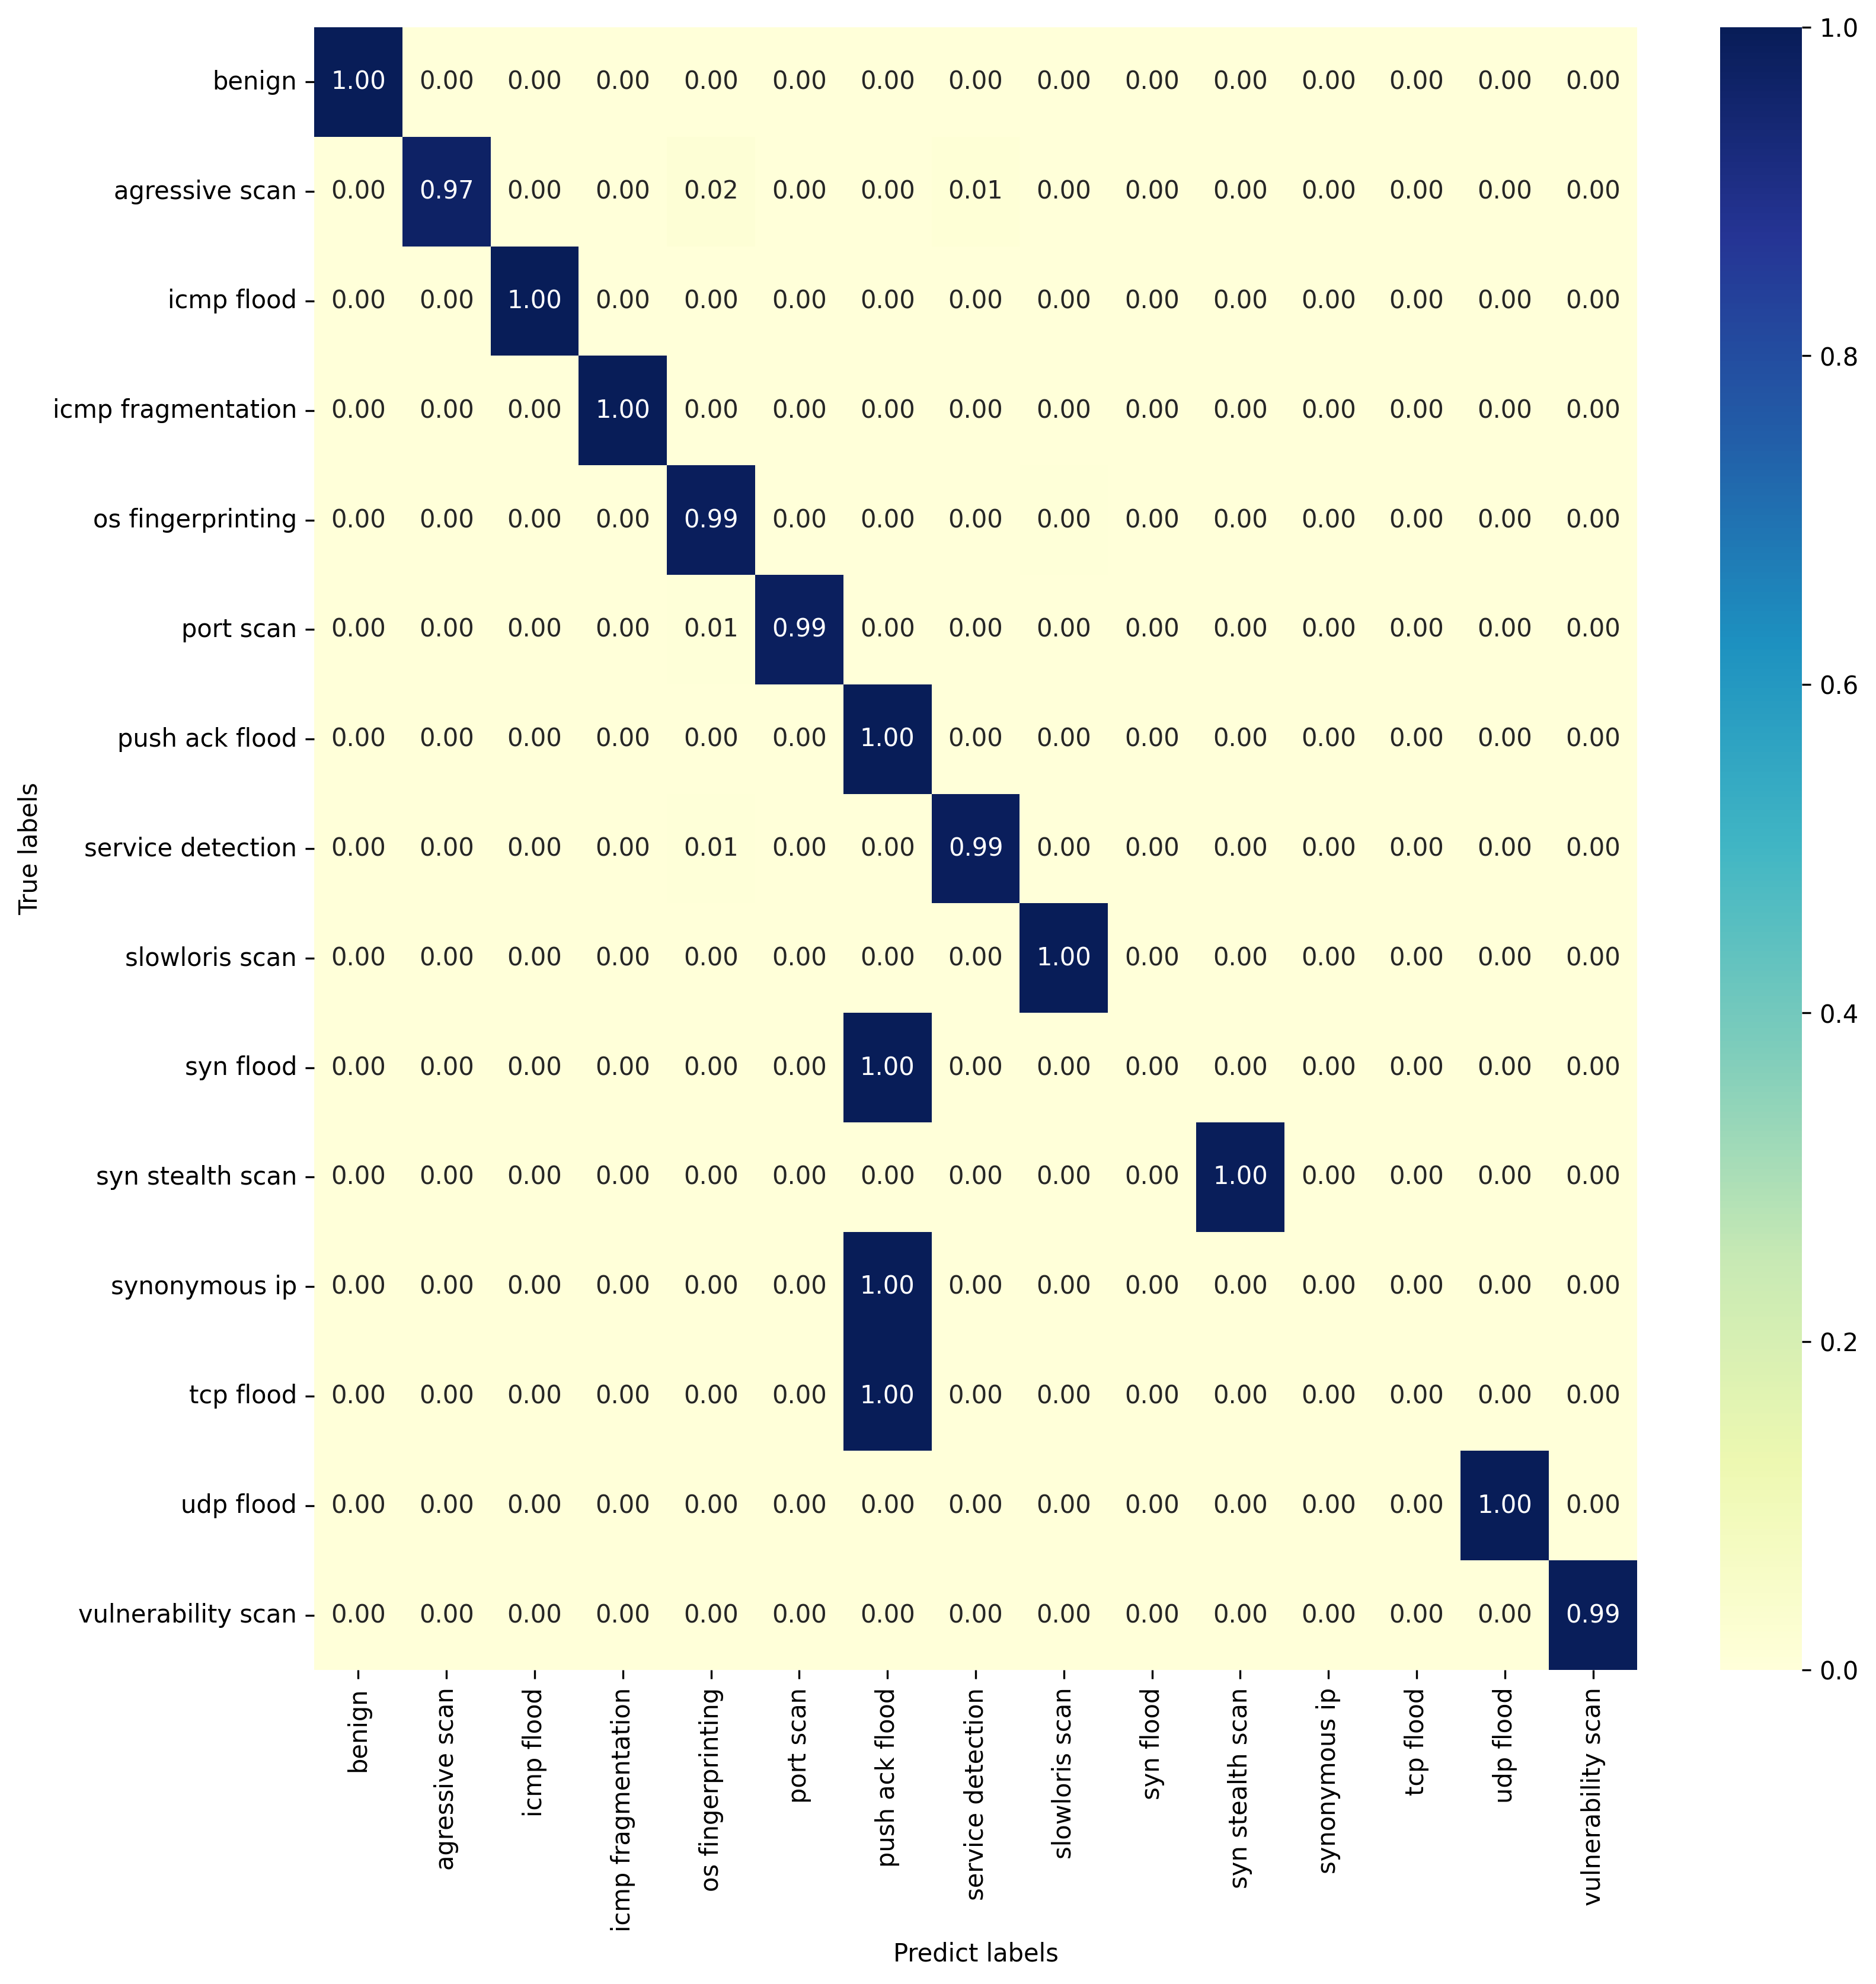

In [10]:
from ml.utils import load_attack_classification_ablation1_model
# plot dpi
mpl.rcParams['figure.dpi'] = 300

# model path
macross_minus_frequency_feature_model_path = 'ablation/macross_minus_frequency_feature.model'

# test data path
ablation1_classification_test_data_path = 'train_test_data/attack_classification/test.parquet'

ablation1 = load_attack_classification_ablation1_model(macross_minus_frequency_feature_model_path, gpu=True)

ablation1_cm = confusion_matrix(
    data_path=ablation1_classification_test_data_path,
    model=ablation1,
    num_class=len(ID_TO_ATTACK)
)

attack_labels = []
for i in sorted(list(ID_TO_ATTACK.keys())):
    attack_labels.append(ID_TO_ATTACK[i])

plot_confusion_matrix(ablation1_cm, attack_labels)

get_classification_report(ablation1_cm, attack_labels)

/home/why23/anaconda3/envs/macross/lib/python3.10/site-packages/pytorch_lightning/utilities/cloud_io.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f

,label,acurracy,f1score,precision,recall
0,benign,0.91195,0.993906,0.992257,0.995560
1,agressive scan,0.91195,0.975583,0.975583,0.975583
2,icmp flood,0.91195,0.999445,1.000000,0.998890
3,icmp fragmentation,0.91195,0.997218,1.000000,0.994451
4,os fingerprinting,0.91195,0.980088,0.976847,0.983352
5,port scan,0.91195,0.988877,0.991081,0.986681
6,push ack flood,0.91195,0.930586,0.909862,0.952275
7,service detection,0.91195,0.978723,0.987571,0.970033
8,slowloris scan,0.91195,0.987243,0.986696,0.987791
9,syn flood,0.91195,0.027837,0.393939,0.014428


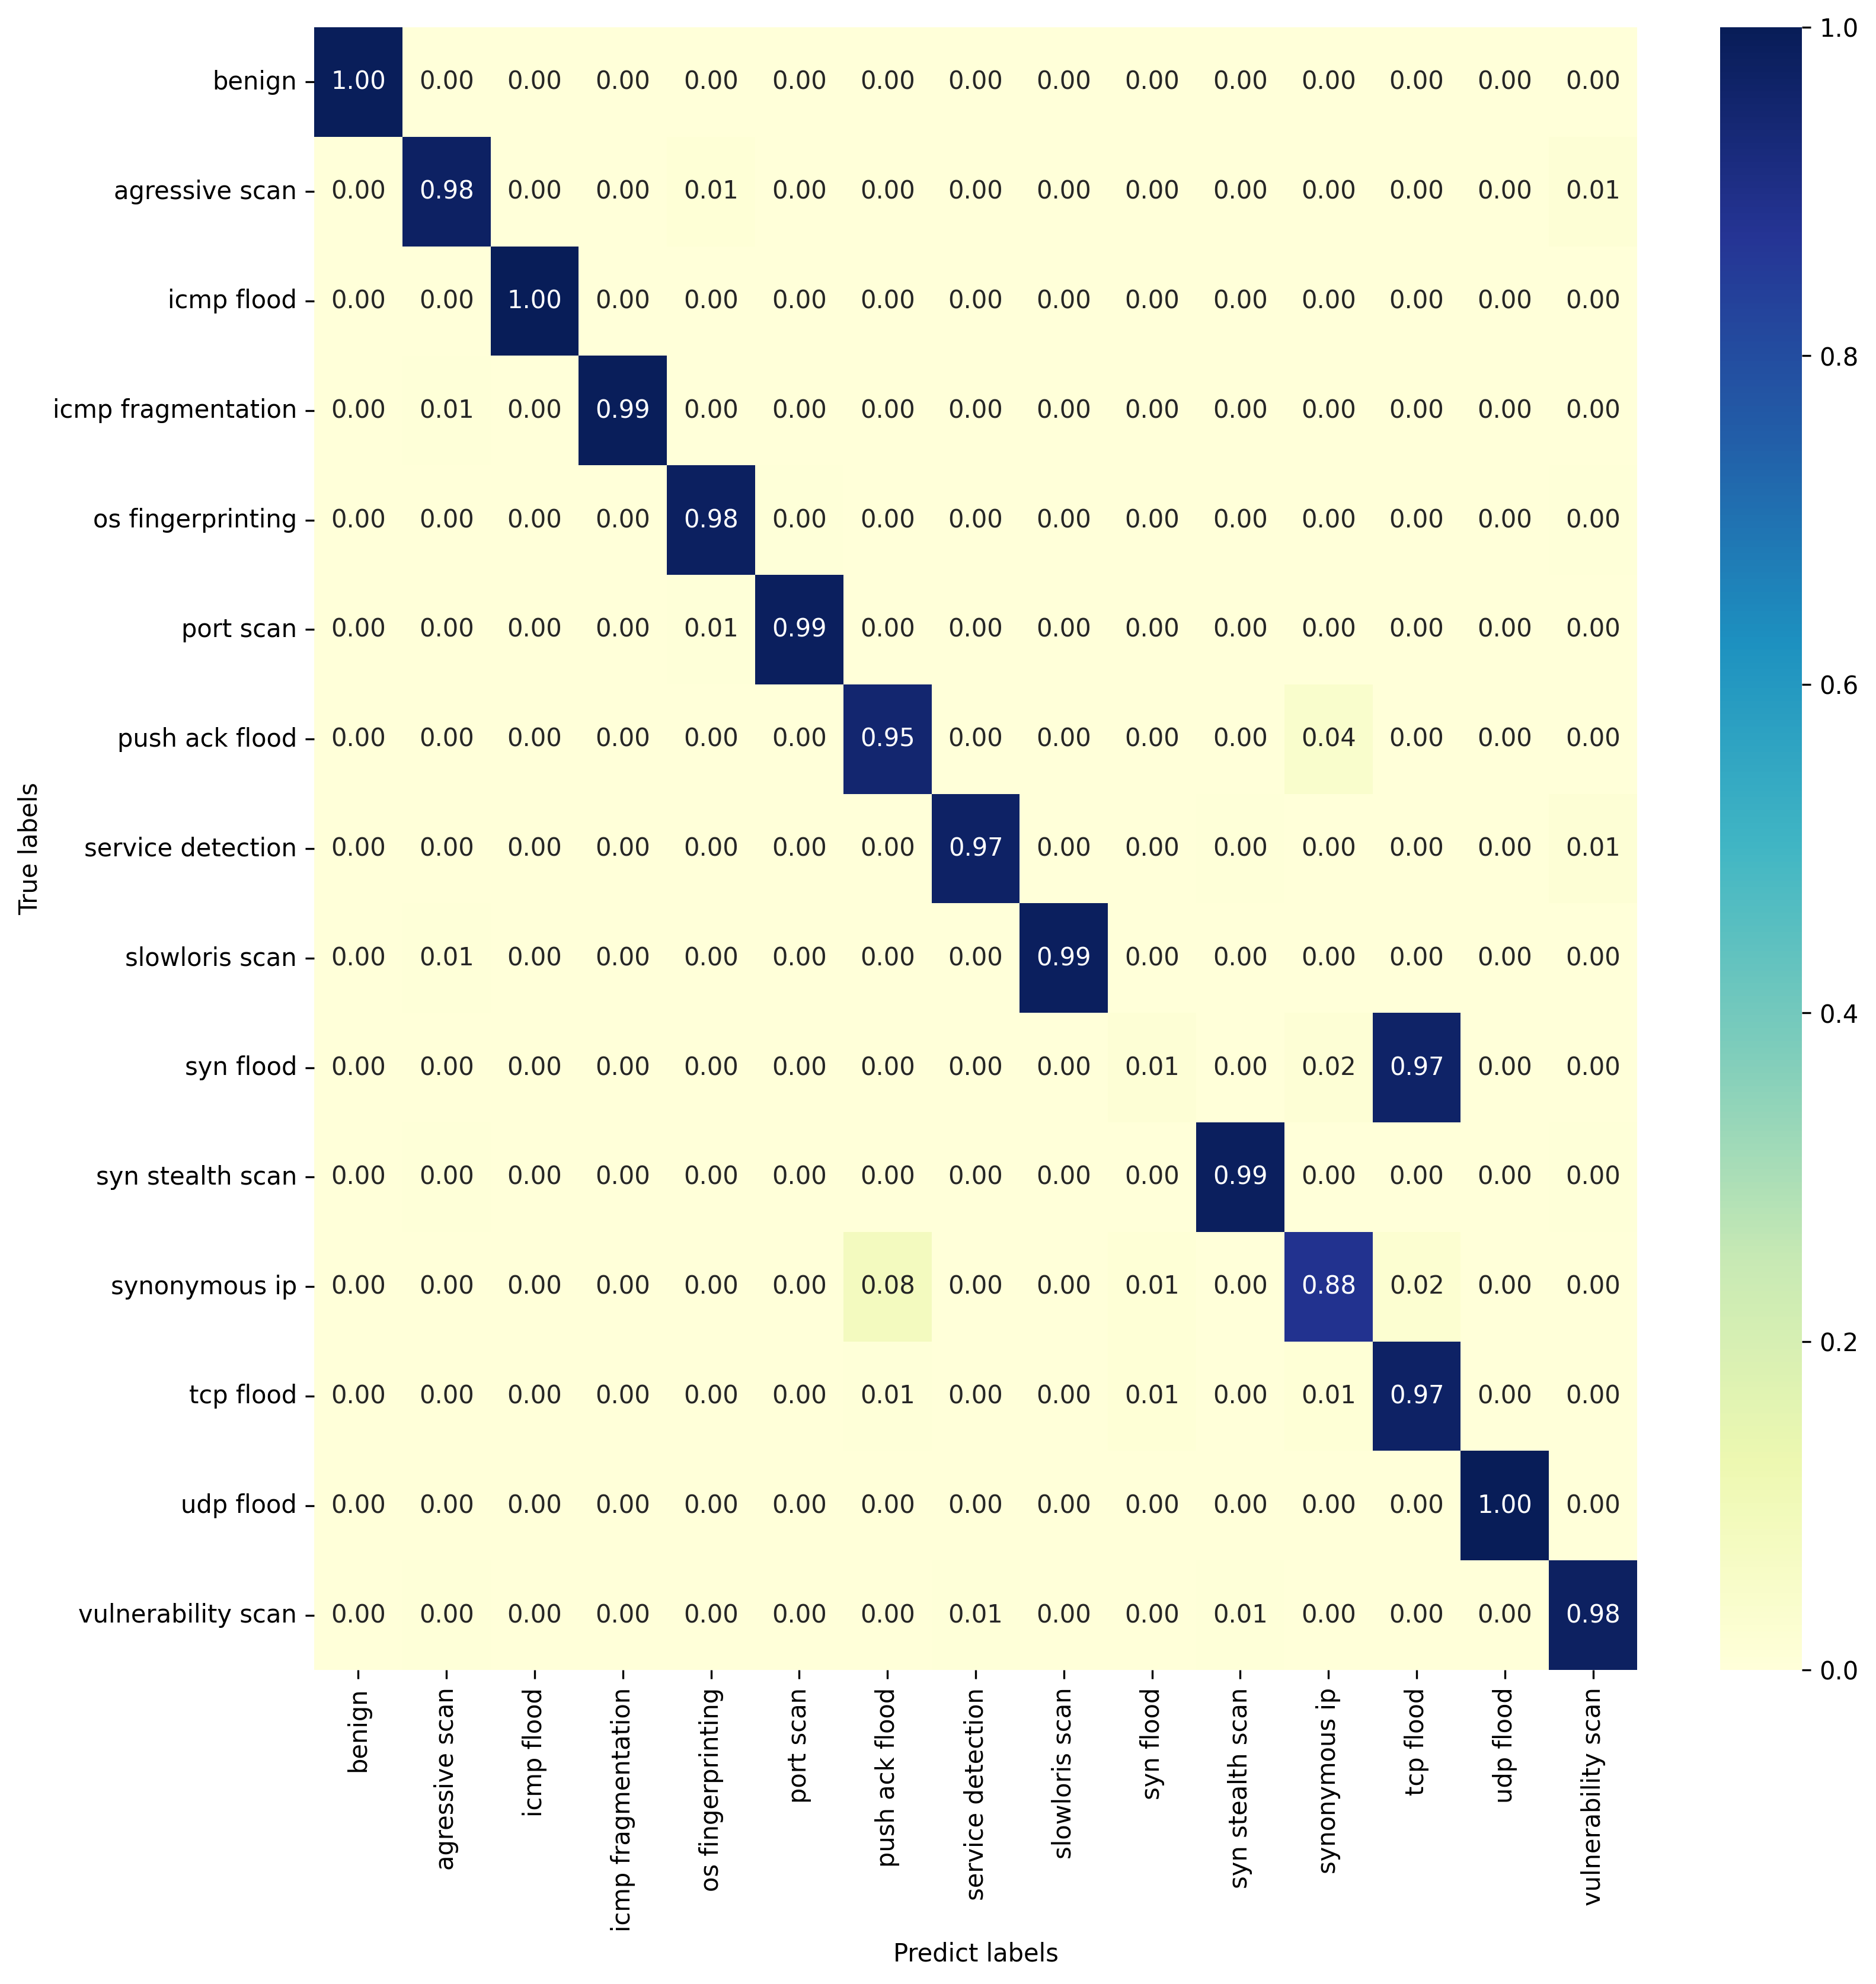

In [11]:
from ml.utils import load_attack_classification_ablation2_model
# plot dpi
mpl.rcParams['figure.dpi'] = 300

# model path
macross_minus_temporal_feature_model_path = 'ablation/macross_minus_temporal_feature.model'

# test data path
ablation2_classification_test_data_path = 'train_test_data/attack_classification/test.parquet'

ablation2 = load_attack_classification_ablation2_model(macross_minus_temporal_feature_model_path, gpu=True)

ablation2_cm = confusion_matrix(
    data_path=ablation2_classification_test_data_path,
    model=ablation2,
    num_class=len(ID_TO_ATTACK)
)

attack_labels = []
for i in sorted(list(ID_TO_ATTACK.keys())):
    attack_labels.append(ID_TO_ATTACK[i])

plot_confusion_matrix(ablation2_cm, attack_labels)

get_classification_report(ablation2_cm, attack_labels)

/home/why23/anaconda3/envs/macross/lib/python3.10/site-packages/pytorch_lightning/utilities/cloud_io.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f

,label,acurracy,f1score,precision,recall
0,benign,0.961524,0.992822,0.987912,0.997780
1,agressive scan,0.961524,0.974157,0.986348,0.962264
2,icmp flood,0.961524,0.999445,0.998891,1.000000
3,icmp fragmentation,0.961524,1.000000,1.000000,1.000000
4,os fingerprinting,0.961524,0.981798,0.975877,0.987791
5,port scan,0.961524,0.990550,0.992205,0.988901
6,push ack flood,0.961524,0.999445,1.000000,0.998890
7,service detection,0.961524,0.987709,0.994376,0.981132
8,slowloris scan,0.961524,0.988288,0.993274,0.983352
9,syn flood,0.961524,0.803037,0.701493,0.938957


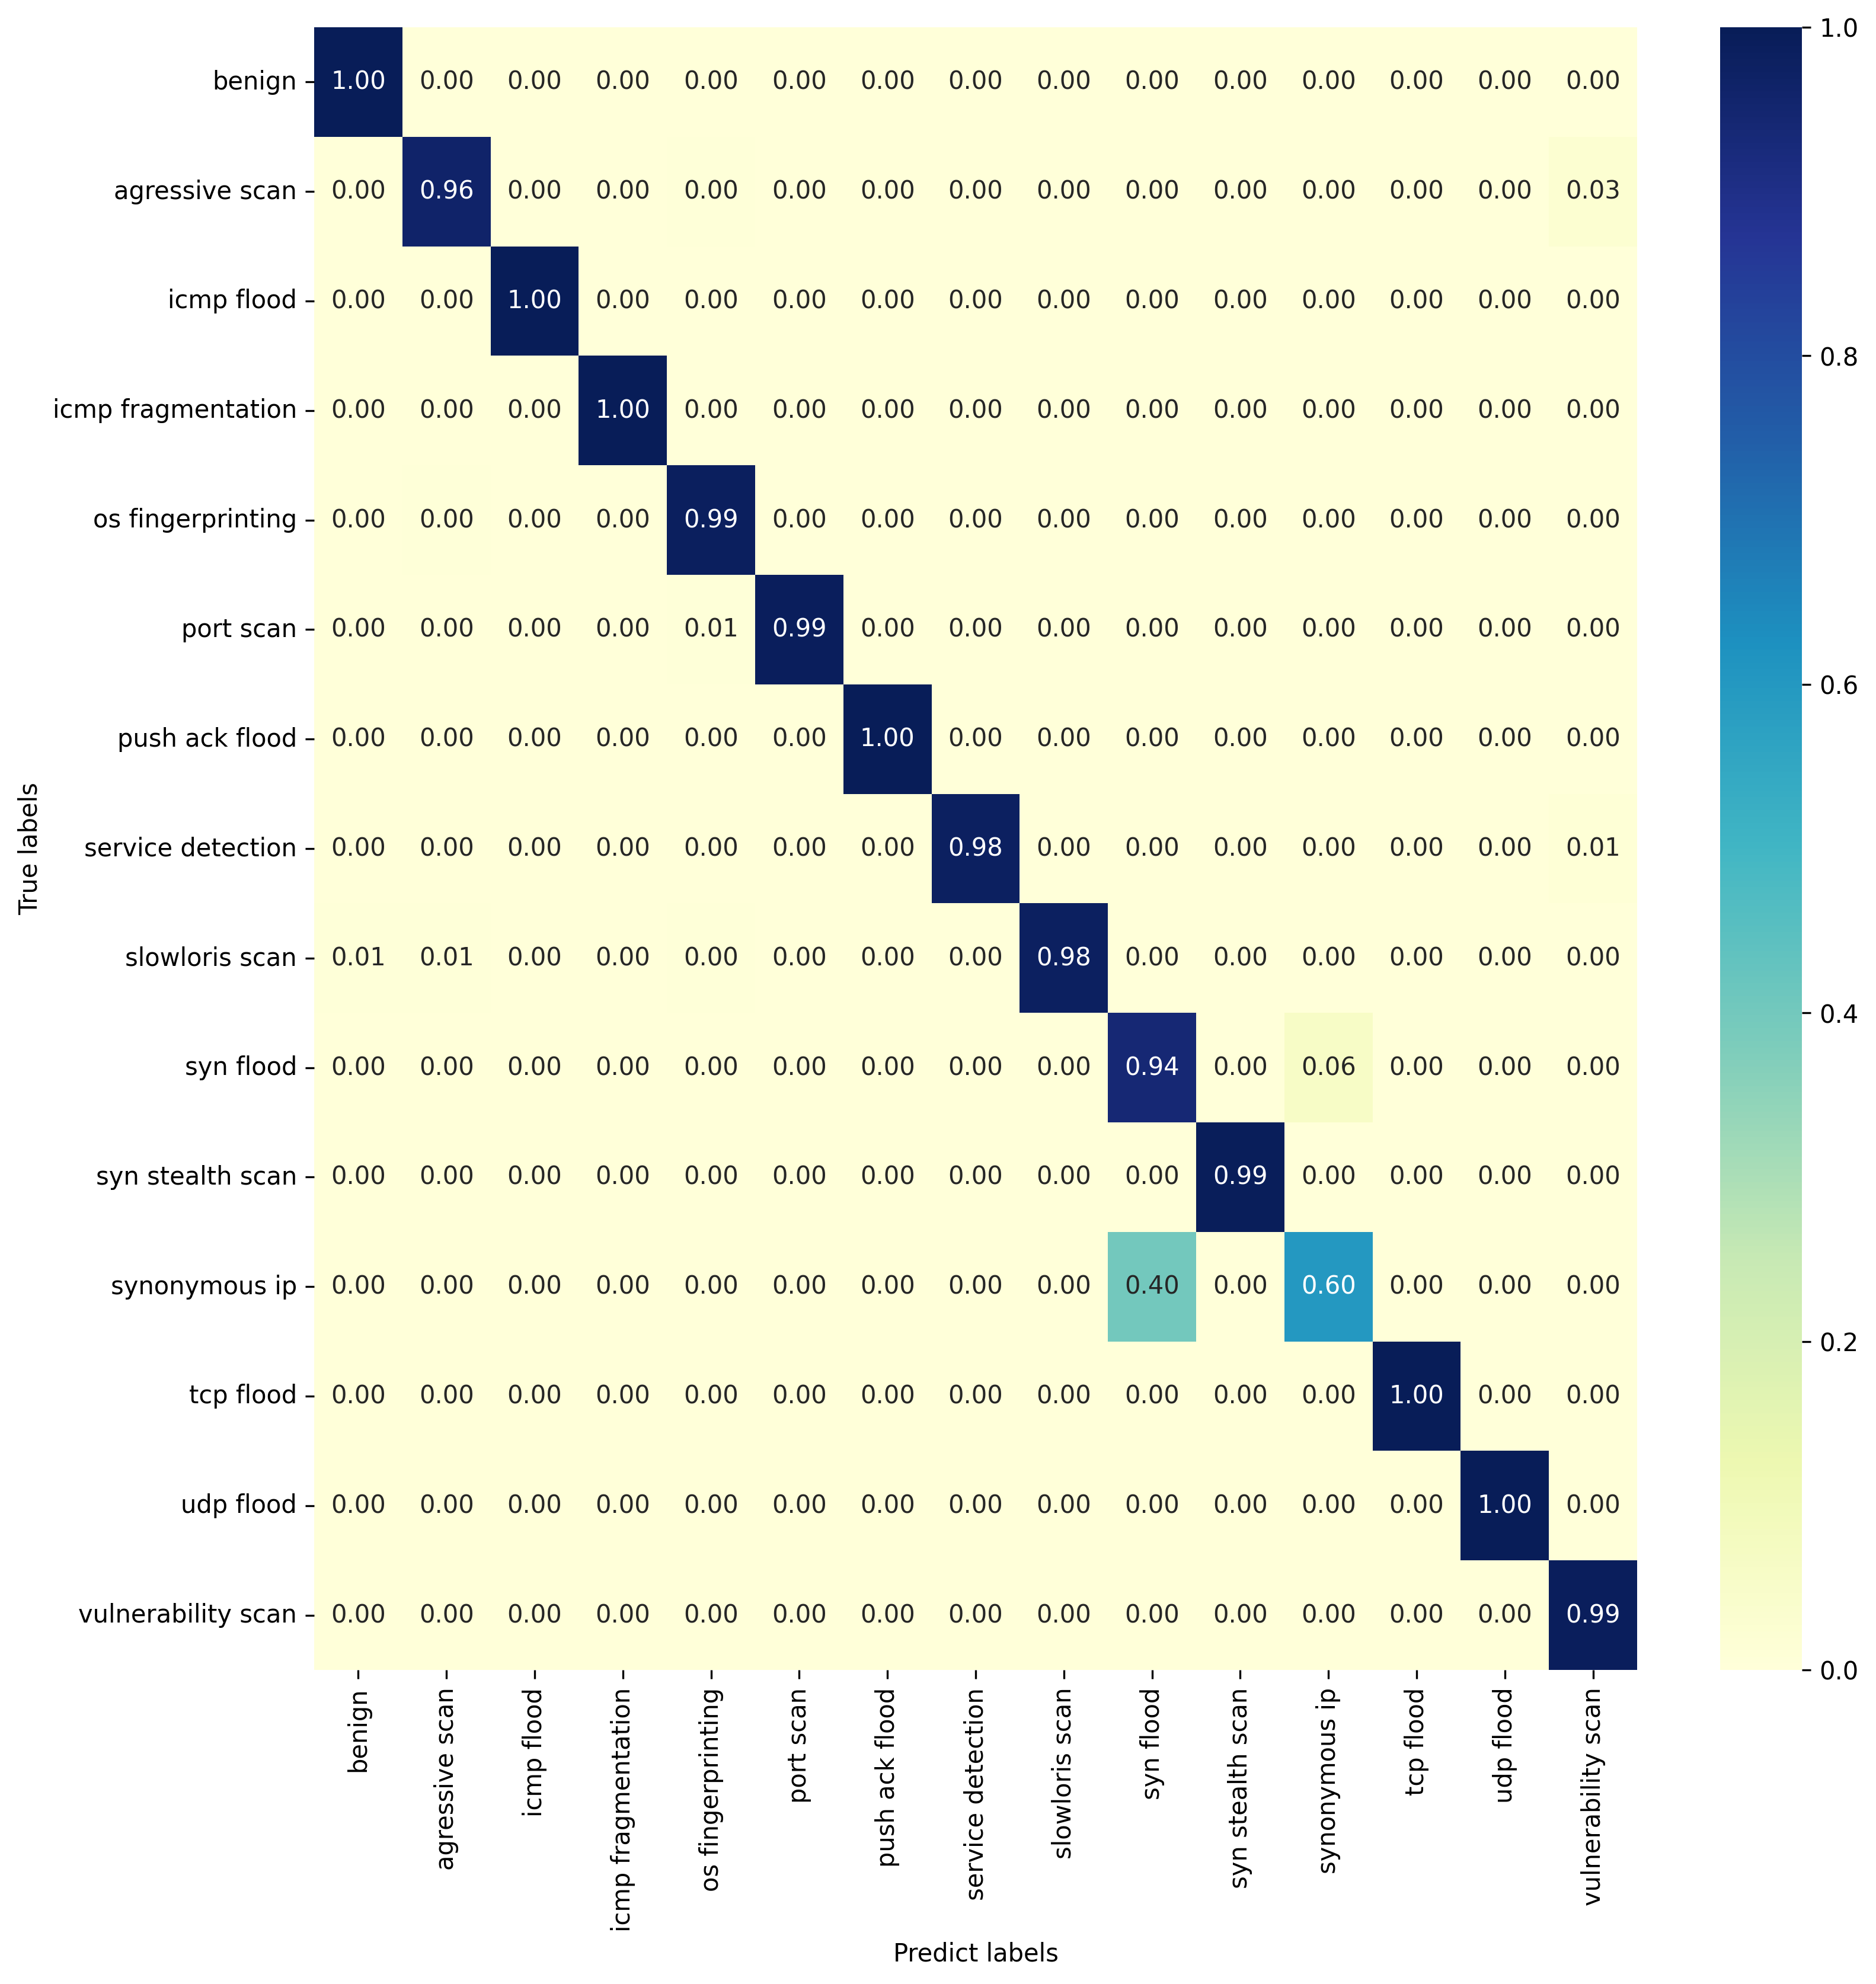

In [12]:
from ml.utils import load_attack_classification_ablation3_model
# plot dpi
mpl.rcParams['figure.dpi'] = 300

# model path
macross_minus_feature_fusion_model_path = 'ablation/macross_minus_feature_fusion.model'

# test data path
ablation3_classification_test_data_path = 'train_test_data/attack_classification/test.parquet'

ablation3 = load_attack_classification_ablation3_model(macross_minus_feature_fusion_model_path, gpu=True)

ablation3_cm = confusion_matrix(
    data_path=ablation1_classification_test_data_path,
    model=ablation3,
    num_class=len(ID_TO_ATTACK)
)

attack_labels = []
for i in sorted(list(ID_TO_ATTACK.keys())):
    attack_labels.append(ID_TO_ATTACK[i])

plot_confusion_matrix(ablation3_cm, attack_labels)

get_classification_report(ablation3_cm, attack_labels)

/home/why23/anaconda3/envs/macross/lib/python3.10/site-packages/pytorch_lightning/utilities/cloud_io.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f

,label,acurracy,f1score,precision,recall
0,benign,0.920755,0.995030,0.990110,1.000000
1,agressive scan,0.920755,0.979225,0.990909,0.967814
2,icmp flood,0.920755,0.999445,0.998891,1.000000
3,icmp fragmentation,0.920755,1.000000,1.000000,1.000000
4,os fingerprinting,0.920755,0.980588,0.980044,0.981132
5,port scan,0.920755,0.991625,0.997753,0.985572
6,push ack flood,0.920755,0.967742,0.953664,0.982242
7,service detection,0.920755,0.979547,0.975771,0.983352
8,slowloris scan,0.920755,0.985189,0.973970,0.996670
9,syn flood,0.920755,0.507463,0.505507,0.509434


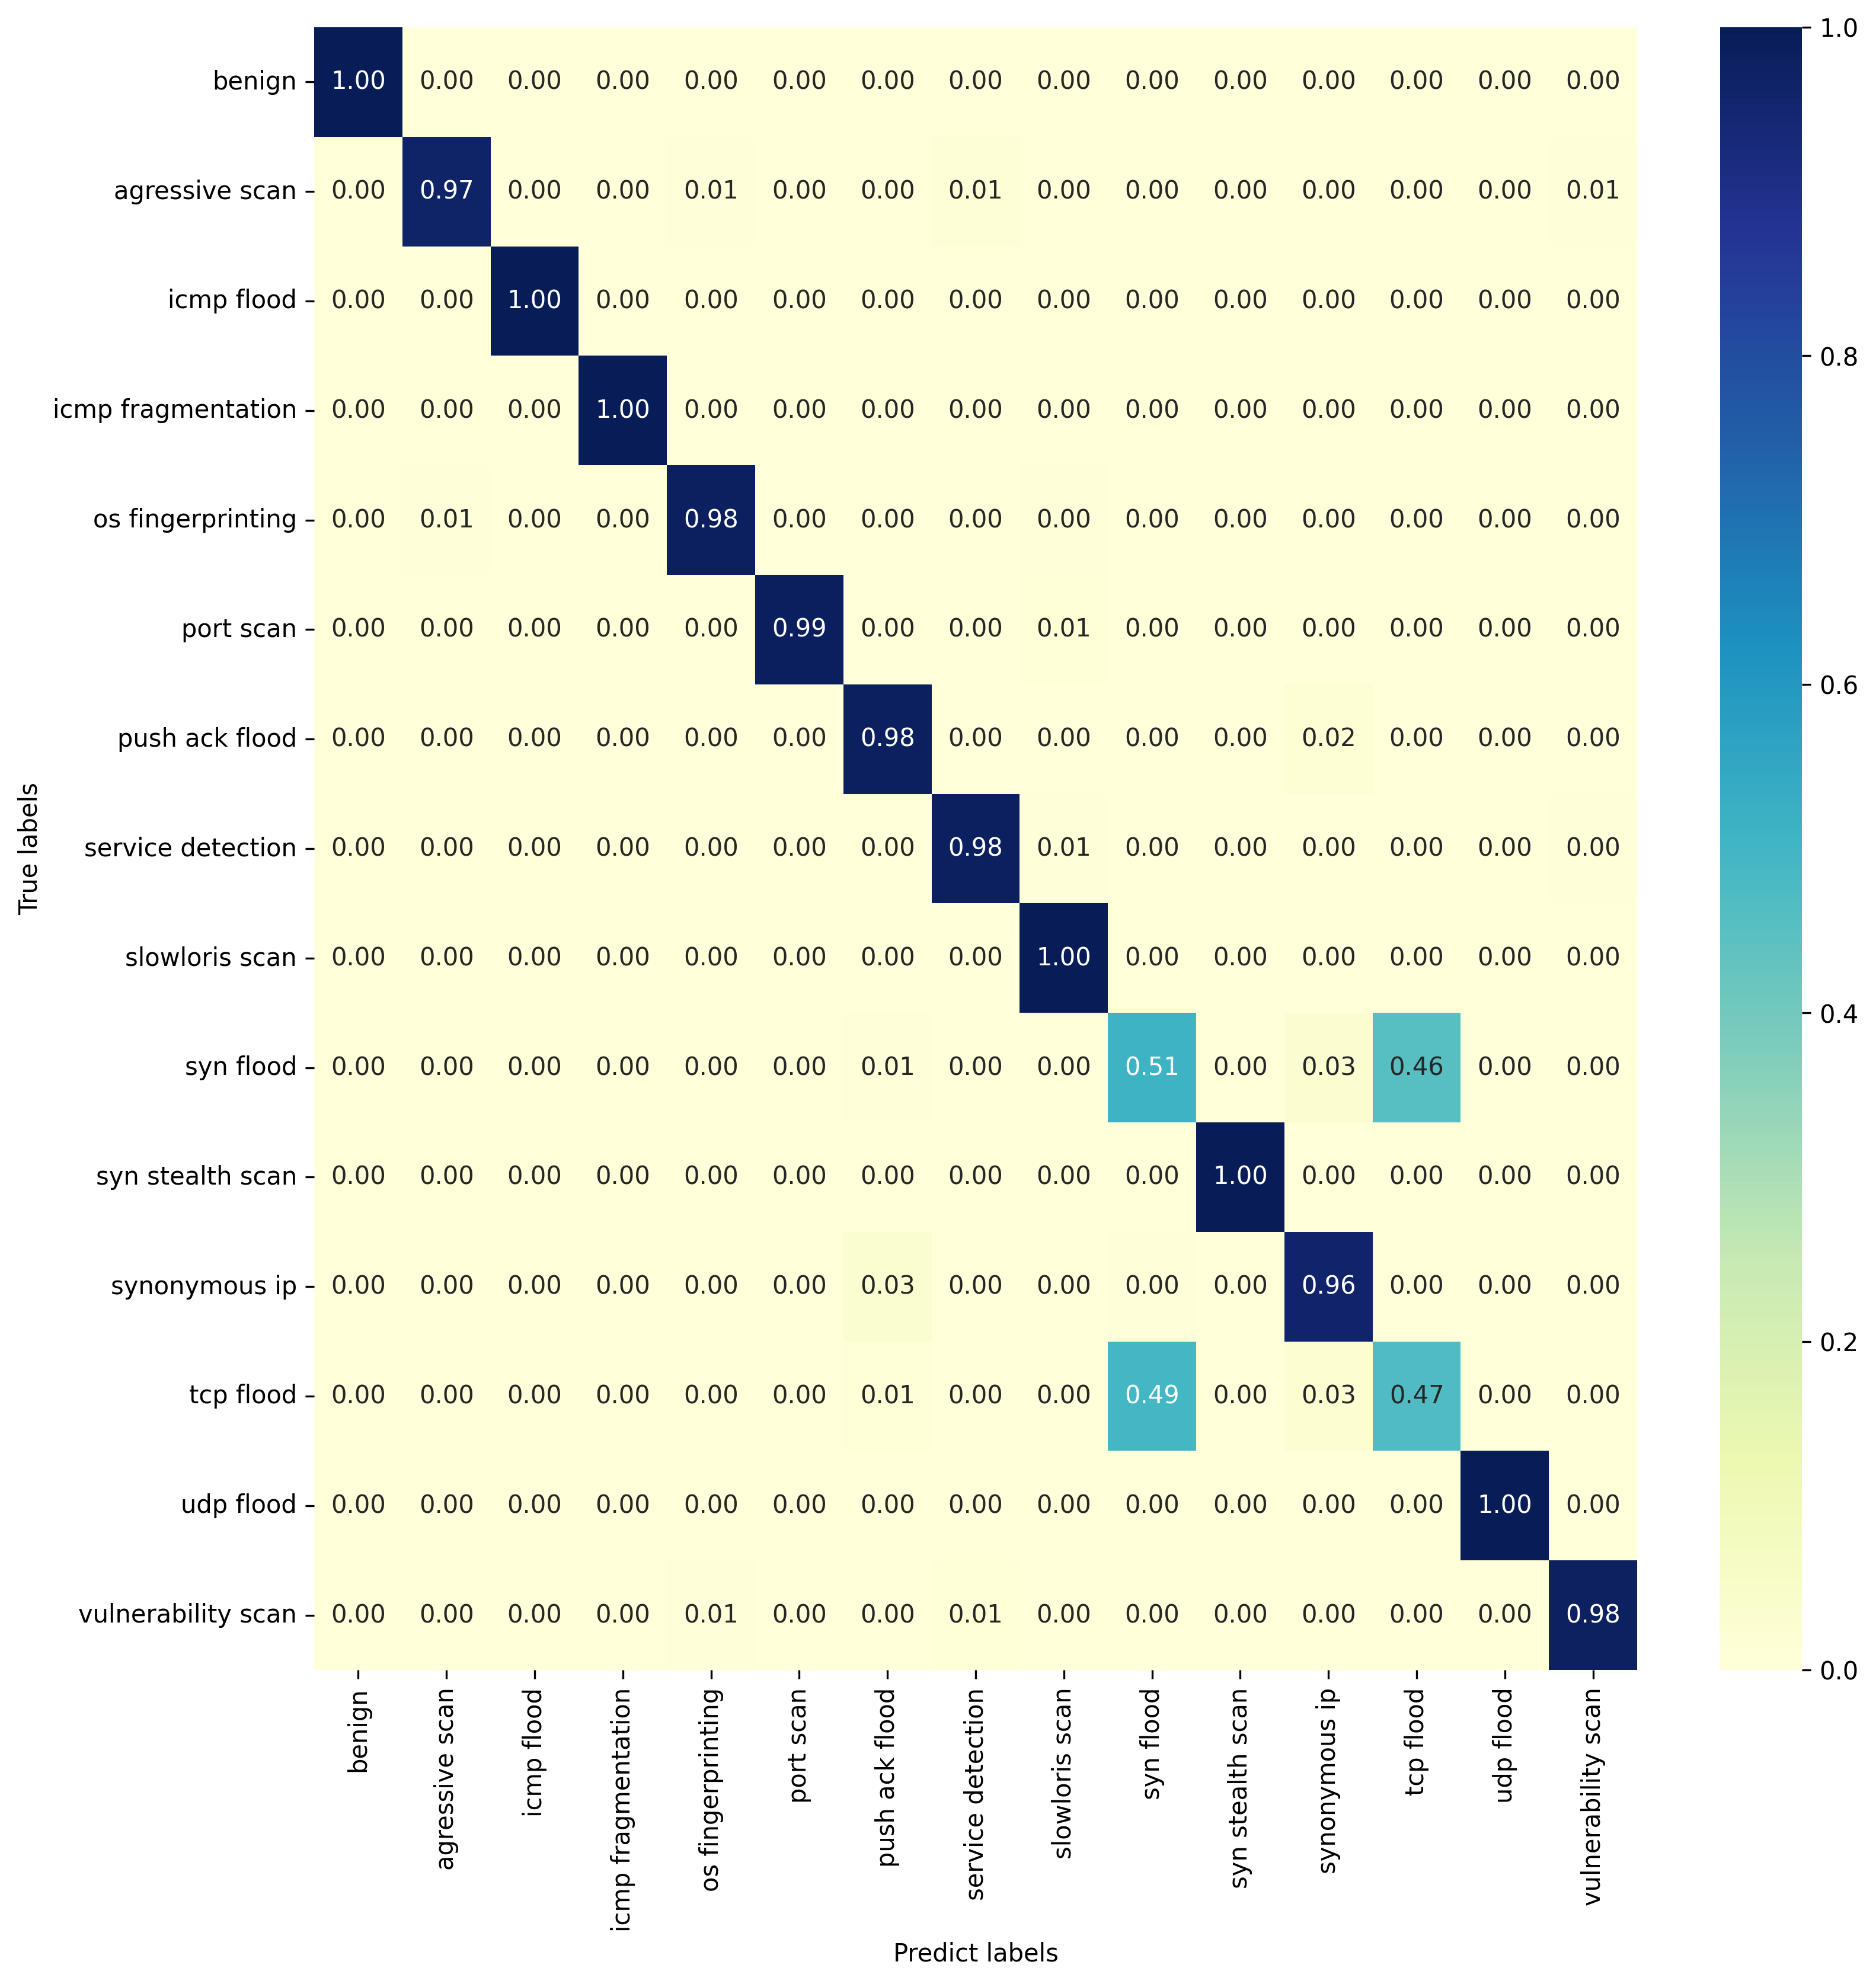

In [13]:
from ml.utils import load_attack_classification_ablation4_model
# plot dpi
mpl.rcParams['figure.dpi'] = 300

# model path
macross_minus_fusionfeature_extraction_model_path = 'ablation/macross_minus_fusionfeature_extraction.model'

# test data path
ablation4_classification_test_data_path = 'train_test_data/attack_classification/test.parquet'

ablation4 = load_attack_classification_ablation4_model(macross_minus_fusionfeature_extraction_model_path, gpu=True)

ablation4_cm = confusion_matrix(
    data_path=ablation4_classification_test_data_path,
    model=ablation4,
    num_class=len(ID_TO_ATTACK)
)

attack_labels = []
for i in sorted(list(ID_TO_ATTACK.keys())):
    attack_labels.append(ID_TO_ATTACK[i])

plot_confusion_matrix(ablation4_cm, attack_labels)

get_classification_report(ablation4_cm, attack_labels)